# Density-Based Spatial Clustering of Applications with Noise

Despite the complicated (and long) name, DBSCAN is supprisingly simple to impliment: Find core points and link them together.

Here we will work through an example of how to impliment DBSCAN.

This methods are not necessarily the fastest or most efficient way to run DBSCAN but it should give you a good feeling for how it works. And there is nothing stopping you optimising the method we will explore, or writing something even faster. It also uses some of the most basic Python libraries, so is simple to impliment by design. 

Let's include our libraries

In [1]:
import numpy as np              #To make some operations easier
import matplotlib.pyplot as plt #To see what we are doing

#####################
from copy import deepcopy       #I want to be able to copy something
#####################

## Some Data
To run FoF, we need some data. To get used to the method, we will create a toy set of data. We will do this by randomly sampling a small amount of data from three Gaussian Distributions.

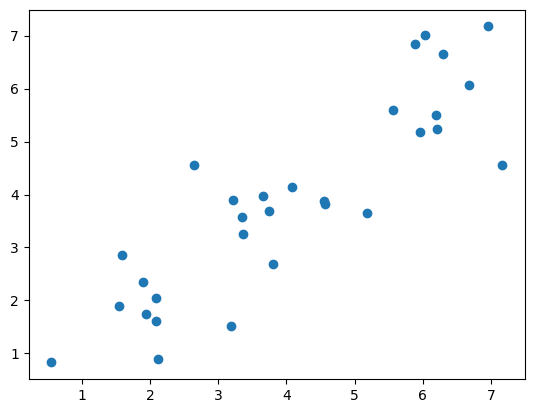

In [2]:
#While we play around, we want our results to be repeatable. So let's set a seed
np.random.seed(256)

#Draw 10 random points from a 2D Gaussian with
point_1 = np.random.multivariate_normal([2,2], [[0.75,0],[0,0.5]], 10) #mean=[2,2] and std=[0.75,0.5]
point_2 = np.random.multivariate_normal([6,6], [[0.5,0],[0,0.75]], 10) #mean=[6,6] and std=[0.5,0.75]
point_3 = np.random.multivariate_normal([4,4], [[0.5,0],[0,0.5]], 10)  #mean=[4,4] and std=[0.5,0.5]

#Join our points together into one list
points = np.vstack((point_1, point_2, point_3))
idx = np.arange(0, len(points))

#As the order of points shouldn't matter, let's shuffle them
np.random.shuffle(idx)
points = points[idx]

#Plot the points to see where we are starting from
plt.scatter(points[:,0], points[:,1])
plt.show()

If you made some dimensionally reduced data this morning, you can load that insead if you prefer.

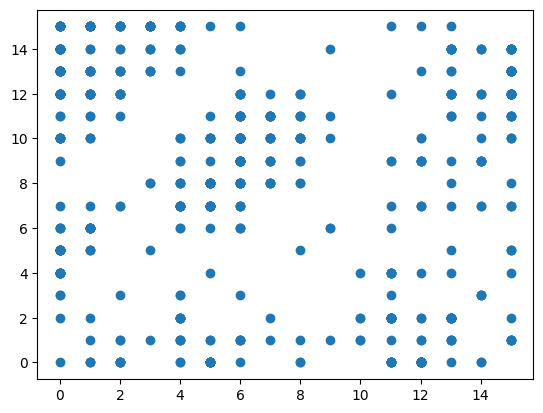

In [3]:
#Load our data from this morning
data_source = 'SOM' #'TSVD', 'PCA', or "SOM
points = np.load(data_source+'_Z.npy')

#####################
#If we are using the SOM data, we have many points in one position
#To make things easier, we will only use unique positions
#if data_source == 'SOM':
#    points_tupl = [tuple(elem) for elem in points]
#    points = []
#    for pt in points_tupl:
#        if pt not in points:
#            points.append(pt)
#    points = np.array(points)
#####################

#As the order of points shouldn't matter, let's shuffle them
idx = np.arange(0, len(points))
np.random.shuffle(idx)
points = points[idx]

#Plot the points to see where we are starting from
plt.scatter(points[:,0], points[:,1])
plt.show()

## Find core points

To start we need to find the points that contain rho points (including themself) within epsilon. This also means we need to define rho and epsilon.

In [4]:
rho = 5
epsilon = np.sqrt(2)+0.01

In [5]:
def find_cores(points, rho, epsilon):

    #####################
    cores = {}
    for i in range(0, len(points)):
        dists = np.sqrt(np.square(points[i,0]-points[:,0])+np.square(points[i,1]-points[:,1]))
        friends = np.where(dists < epsilon)[0]
        if len(friends) >= rho:
            cores[i] = friends.tolist()
    #####################
    
    return cores

cores = find_cores(points, rho, epsilon)

## Join core clusters

We have our core points, now we need to join them together to form the clusters.
Remember, core points can only be linked through other core points.

In [6]:
def get_clusters(points, cores):

    #####################
    clusters = deepcopy(cores)
    keys = list(clusters.keys())
    for i in keys:
        if i not in clusters.keys():
            continue
        friends = clusters[i]
        for f in friends:
            if f == i:
                continue
            if f in clusters.keys():
                clusters[i] += clusters[f]
                del clusters[f]
        clusters[i] = np.unique(clusters[i]).tolist()
    #####################
    
    return clusters

clusters = get_clusters(points, cores)

Remember, each point can only live in one cluster.
If you forgot this, you may need to clean your clusters.
Make sure you remember than each cluster must have more than rho members.

In [7]:
def clean_clusters(clusters, rho):

    #####################
    keys = list(clusters.keys())
    keys.reverse()
    
    for i, key in enumerate(keys):
        if i == 0:
            continue
        #check if members of groups are in previous group        
        for m in clusters[key]:
            for j in keys[:i]:
                if j not in clusters.keys():
                    continue
                if m in clusters[j]:
                    clusters[j].remove(m)
                    if len(clusters[j]) < rho:
                        del clusters[j]
    #####################
    
    return clusters

clusters = clean_clusters(clusters, rho)

## Noise

Don't forget about the points that were not close enough to core points to be in the clusters.
We should probably remember to keep an eye on those in their individual group

In [8]:
def get_noise(points, clusters):
    #####################
    #So far, clusters is a dict
    #I now want clusters to be a list
    new_clusters = []
    for key in clusters.keys():
        new_clusters.append(clusters[key])
    clusters = new_clusters
    
    points_idx = np.arange(0, len(points))
    clusters_idx = []
    for cluster in clusters:
        clusters_idx += cluster
    clusters_idx = np.array(clusters_idx)
    
    loners = np.setdiff1d(points_idx, clusters_idx)
    for lone in loners:
        clusters.append([int(lone)])
    #####################
        
    return clusters

clusters = get_noise(points, clusters)

## See what we got

Now is a good time to plot our clusters to see what we have found. I would write the code to do this for you but I have no idea how your data is structured. I would suggest using different colours for each cluster so you can visually see the clusters you found.

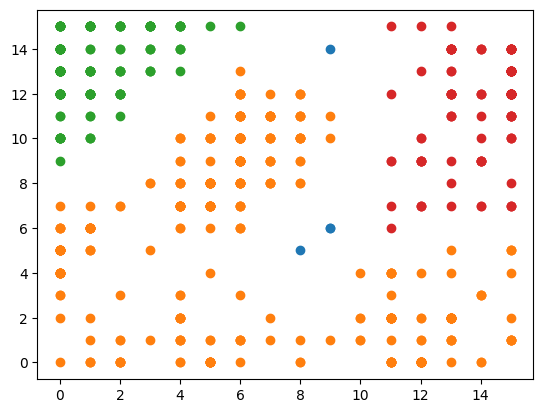

In [9]:
def plot_clusters(points, clusters):
    
    #####################
    colours = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
    
    g = 0
    for group in clusters:
        if len(group) == 1:
            c = 'tab:blue'
        else:
            c = colours[g]
            g += 1
            if g == len(colours):
                g = 0
        plt.scatter(points[group,0], points[group,1], c=c)
    plt.show()
    #####################

    return

plot_clusters(points, clusters)

## DBSCAN is FoF?

If rho is set to 2, yes. Try it and find out!

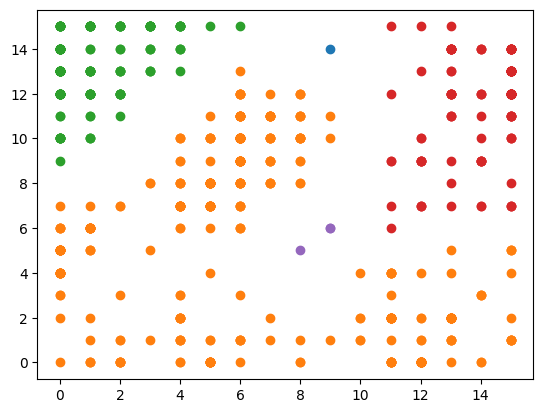

In [10]:
rho = 2
cores = find_cores(points, rho, epsilon)
clusters = get_clusters(points, cores)
clusters = clean_clusters(clusters, rho)
clusters = get_noise(points, clusters)
plot_clusters(points, clusters)

If you did the FoF notebook, the above plot should look pretty familiar (if linking_length = epsilon)

## Real Data

Now let's play with some real data! MorphologicalCat_VISTULA.csv contains morphologies for 10943 galaxies observed by KiDS. Let's grab that data!

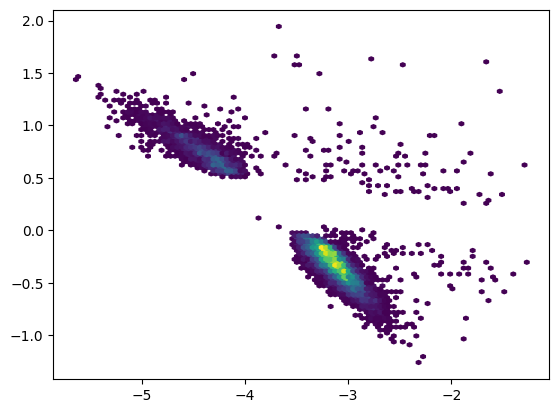

In [11]:
#Load our data from this morning
data_source = 'TSVD' #'TSVD', 'PCA', or "SOM
Z_data = np.load(data_source+'_data.npy')

plt.hexbin(Z_data[:,0], Z_data[:,1], mincnt=1)
plt.show()

Now run your DBSCAN on it and see what we find. Play around with epsilon and rho.

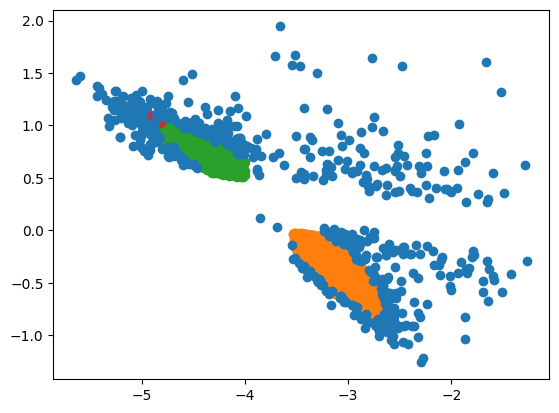

In [13]:
rho = 10
epsilon = 0.03#np.sqrt(2)+0.01

cores = find_cores(Z_data, rho, epsilon)
clusters = get_clusters(Z_data, cores)
clusters = clean_clusters(clusters, rho)
clusters = get_noise(Z_data, clusters)
plot_clusters(Z_data, clusters)

Now we have our clusters, you can go back to our data to better understand what you found.